Inspiration

Get your feet wet with regression techniques here on Kaggle by using this dataset. Perfect for beginners since the OpenIntro Statistics book does a good explanation in Chapter 8.

* Can we use total length to predict a possum's head length?
* Which possum body dimensions are most correlated with age and sex?
* Can we classify a possum's sex by its body dimensions and location?
* Can we predict a possum's trapping location from its body dimensions?


First, import dataset from Kaggle

In [18]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
#plt.style.use('ggplot')

In [20]:
df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "abrambeyer/openintro-possum",
    "possum.csv"
)

In [21]:
print("Initial data examination")
print("------------------------")

print("Head:")
print(df.head())

print()
print("Total cases =", df.shape[0])

print()
print("Data types:")
print(df.dtypes)

Initial data examination
------------------------
Head:
   case  site  Pop sex  age  hdlngth  skullw  totlngth  taill  footlgth  \
0     1     1  Vic   m  8.0     94.1    60.4      89.0   36.0      74.5   
1     2     1  Vic   f  6.0     92.5    57.6      91.5   36.5      72.5   
2     3     1  Vic   f  6.0     94.0    60.0      95.5   39.0      75.4   
3     4     1  Vic   f  6.0     93.2    57.1      92.0   38.0      76.1   
4     5     1  Vic   f  2.0     91.5    56.3      85.5   36.0      71.0   

   earconch   eye  chest  belly  
0      54.5  15.2   28.0   36.0  
1      51.2  16.0   28.5   33.0  
2      51.9  15.5   30.0   34.0  
3      52.2  15.2   28.0   34.0  
4      53.2  15.1   28.5   33.0  

Total cases = 104

Data types:
case          int64
site          int64
Pop          object
sex          object
age         float64
hdlngth     float64
skullw      float64
totlngth    float64
taill       float64
footlgth    float64
earconch    float64
eye         float64
chest       float

In [22]:
print("Range of features")
print("-----------------")

print("Population (note 'other'='New South Wales'|'Queensland'):", df['Pop'].unique())
print("Sex:", df['sex'].unique())

# matplotlib.pyplot.boxplot deprecates vert
# but it yells at me when I use orientation='horizontal'
df.boxplot(vert=False)

Range of features
-----------------
Population (note 'other'='New South Wales'|'Queensland'): ['Vic' 'other']
Sex: ['m' 'f']


<Axes: >

In [23]:
print("Null/NA values")
print("--------------")
na = df.isna()
print("Null values by feature:")
print(na.sum())

print()
print("Total null values =", na.sum().sum())

na_rows = na.any(axis='columns')
print("Total cases with null values =", na_rows.sum())

Null/NA values
--------------
Null values by feature:
case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64

Total null values = 3
Total cases with null values = 3


Since we have only 3/104 (= 2.89%) cases with null values, we choose to simply remove them.

In [26]:
df.dropna()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,100,7,other,m,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,101,7,other,m,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,102,7,other,f,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,103,7,other,m,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


### EDA

In [25]:
import seaborn as sns
import numpy as np

=== Age Distribution ===
count    102.00
mean       3.83
std        1.91
min        1.00
25%        2.25
50%        3.00
75%        5.00
max        9.00
Name: age, dtype: float64


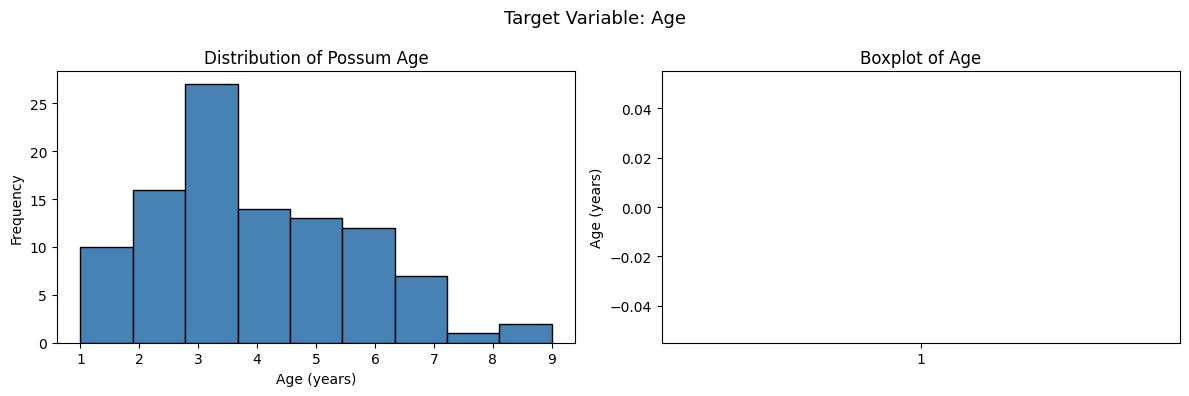

In [ ]:
print("Age Distribution")
print("-----------------")

print(df["age"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["age"], bins=9, edgecolor="black", color="steelblue")
axes[0].set_title("Distribution of Possum Age")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(df["age"])
axes[1].set_title("Boxplot of Age")
axes[1].set_ylabel("Age (years)")

plt.suptitle("Target Variable: Age", fontsize=13)
plt.tight_layout()
plt.show()

Age by Categorical Variables (Sex & Population)
-----------------


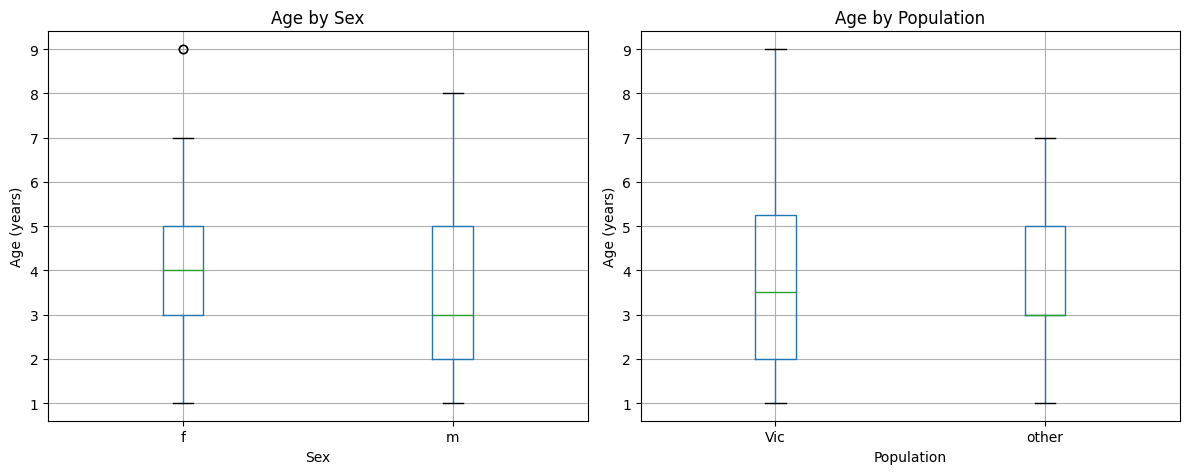

Mean age by sex:
sex
f    3.98
m    3.73
Name: age, dtype: float64

Mean age by population:
Pop
Vic      4.02
other    3.69
Name: age, dtype: float64


In [10]:
print("Age by Categorical Variables (Sex & Population)")
print("-----------------")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column="age", by="sex", ax=axes[0])
axes[0].set_title("Age by Sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Age (years)")

df.boxplot(column="age", by="Pop", ax=axes[1])
axes[1].set_title("Age by Population")
axes[1].set_xlabel("Population")
axes[1].set_ylabel("Age (years)")

plt.suptitle("")  # removes default suptitle
plt.tight_layout()
plt.show()

print("Mean age by sex:")
print(df.groupby("sex")["age"].mean().round(2))
print("\nMean age by population:")
print(df.groupby("Pop")["age"].mean().round(2))

Correlation Heatmap (Numeric Features Only)
-----------------


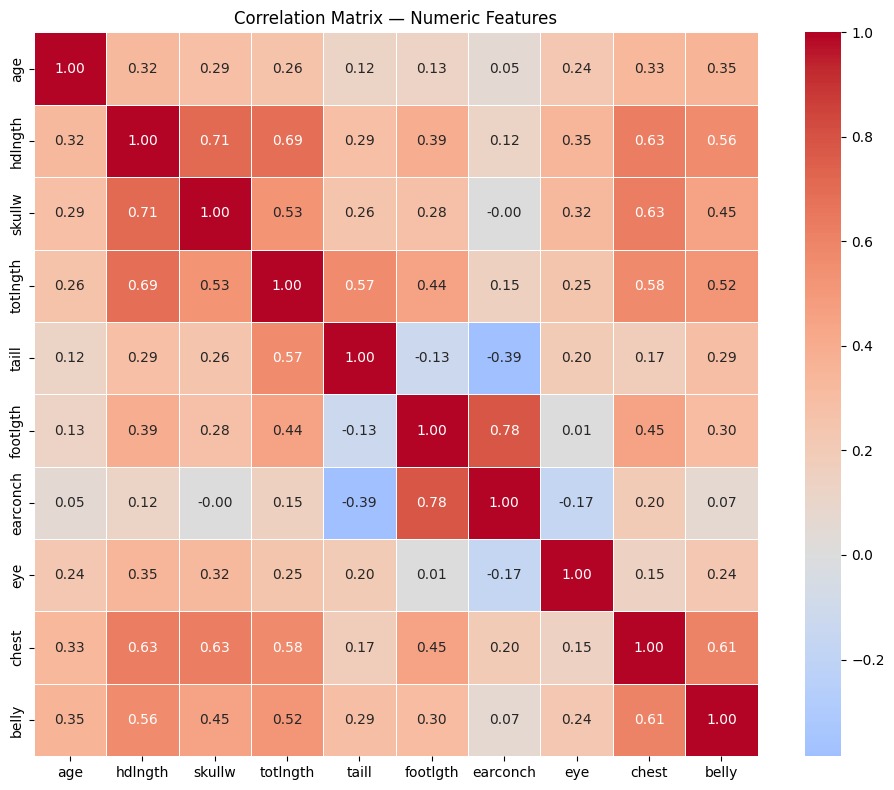


Feature correlations with age (sorted):
belly       0.354
chest       0.334
hdlngth     0.319
skullw      0.285
totlngth    0.260
eye         0.236
footlgth    0.126
taill       0.118
earconch    0.053
Name: age, dtype: float64


In [11]:
print("Correlation Heatmap (Numeric Features Only)")
print("-----------------")

numeric_df = df.drop(columns=["case", "site"]).select_dtypes(include="number")

plt.figure(figsize=(10, 8))
corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

print("\nFeature correlations with age (sorted):")
print(corr_matrix["age"].drop("age").sort_values(ascending=False).round(3))

Scatter Plots: Age vs All Continuous Features
-----------------
Scatter Plots: Age vs All Continuous Features
-----------------


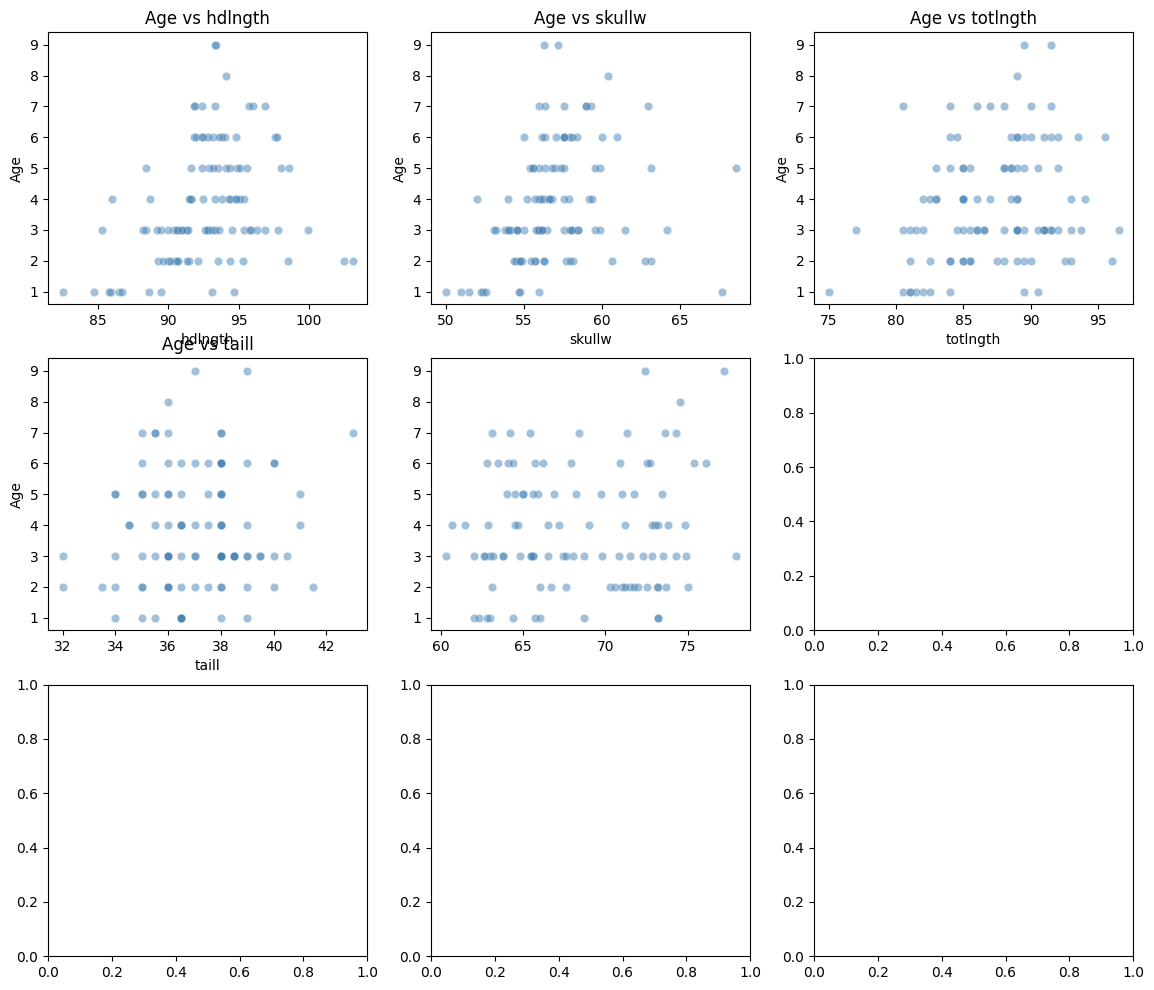

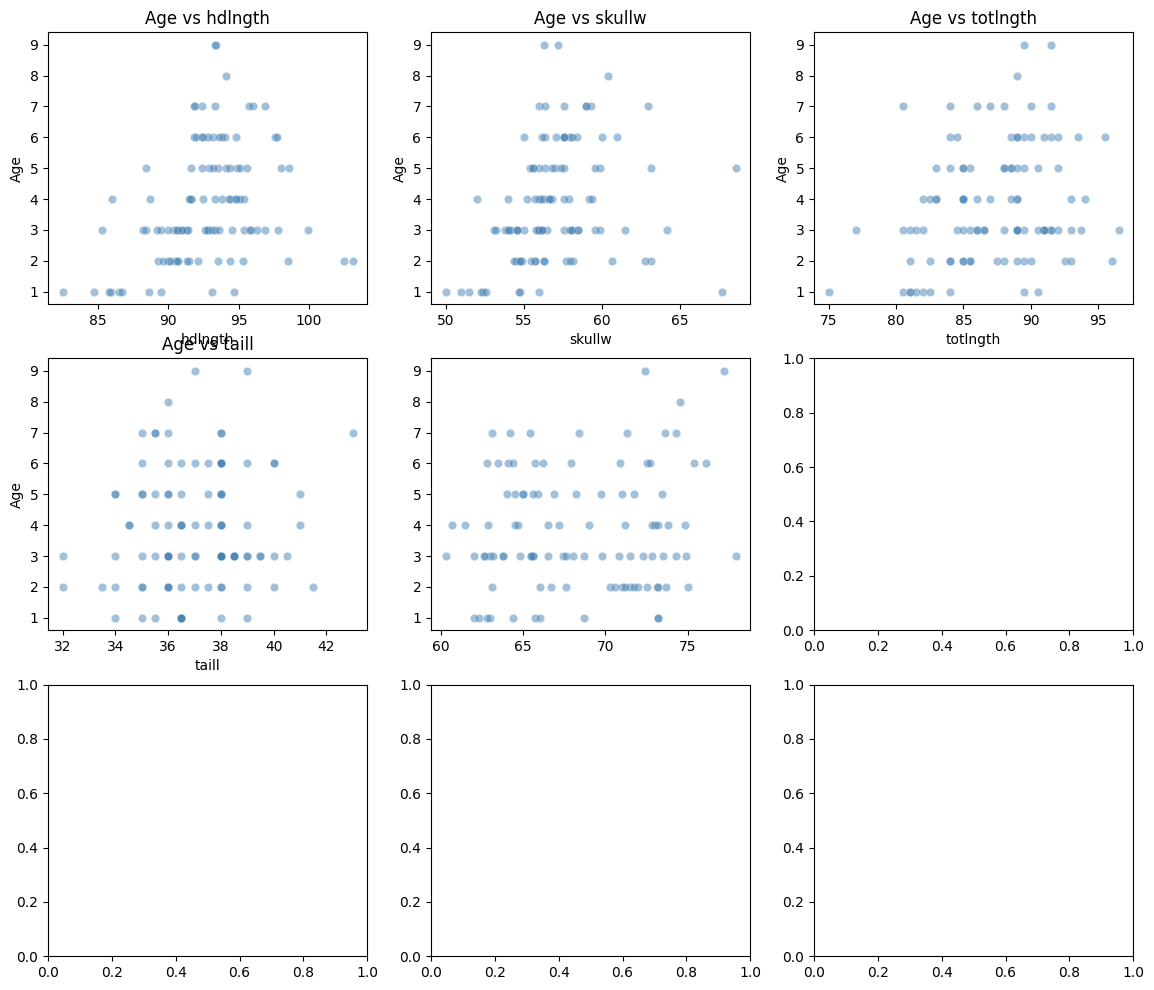

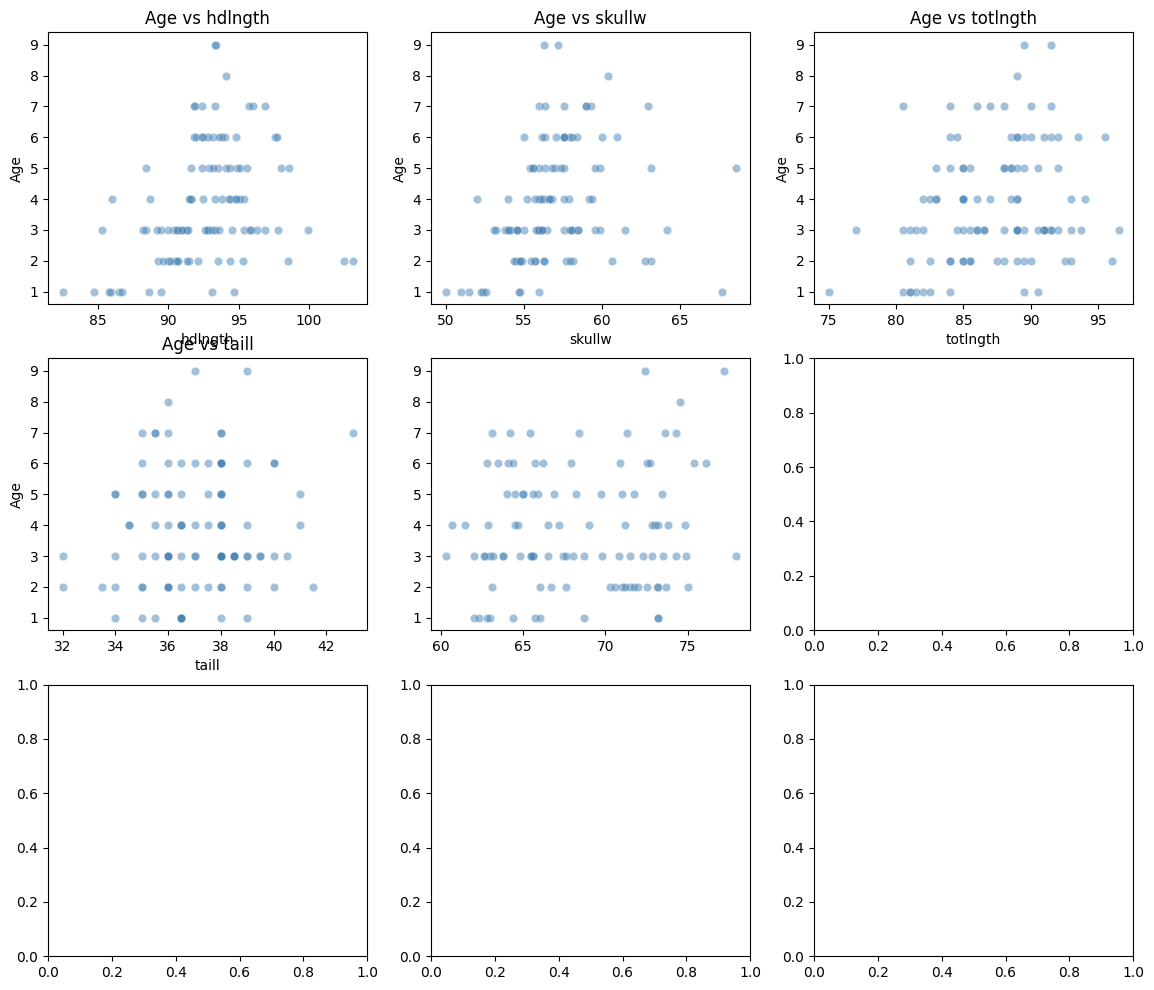

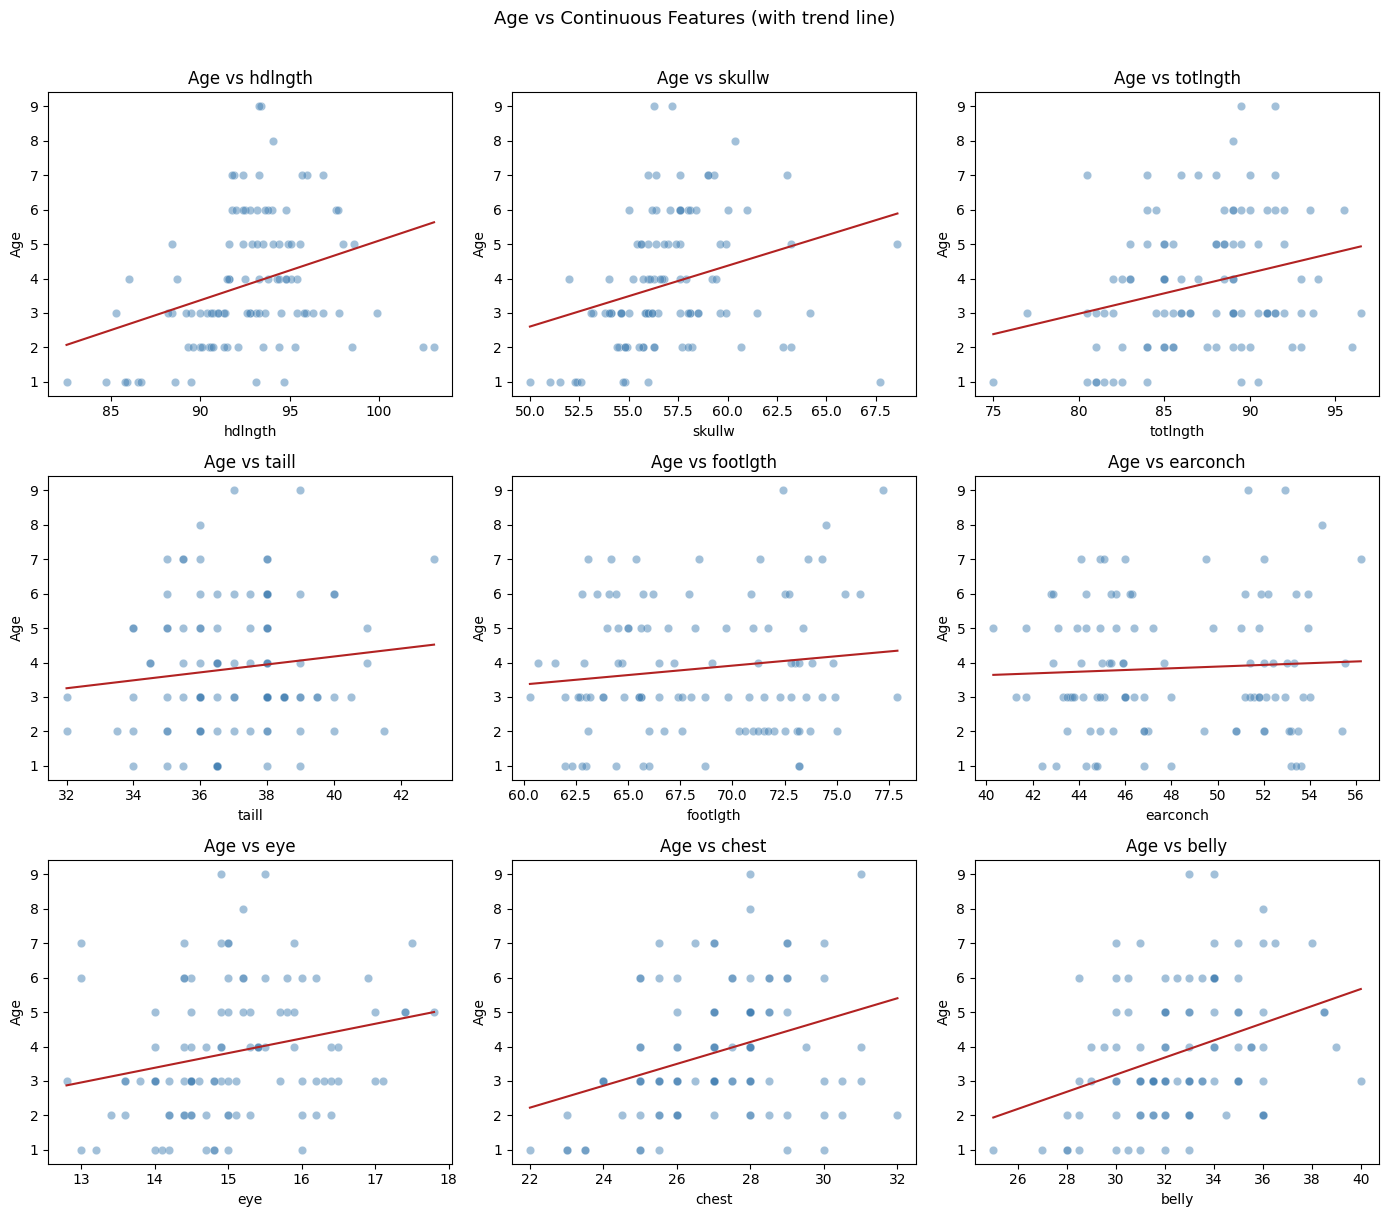

In [ ]:
print("Scatter Plots: Age vs All Continuous Features")
print("-----------------")

continuous_features = ["hdlngth", "skullw", "totlngth", "taill", "footlgth", "earconch", "eye", "chest", "belly"]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    temp = df[[col, "age"]].dropna()  # ← this line is the fix
    axes[i].scatter(temp[col], temp["age"], alpha=0.5, color="steelblue", edgecolors="white", linewidth=0.3)
    m, b = np.polyfit(temp[col], temp["age"], 1)
    x_line = np.linspace(temp[col].min(), temp[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color="firebrick", linewidth=1.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Age")
    axes[i].set_title(f"Age vs {col}")

plt.suptitle("Age vs Continuous Features (with trend line)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Pairplot of Top Correlated Features
-----------------


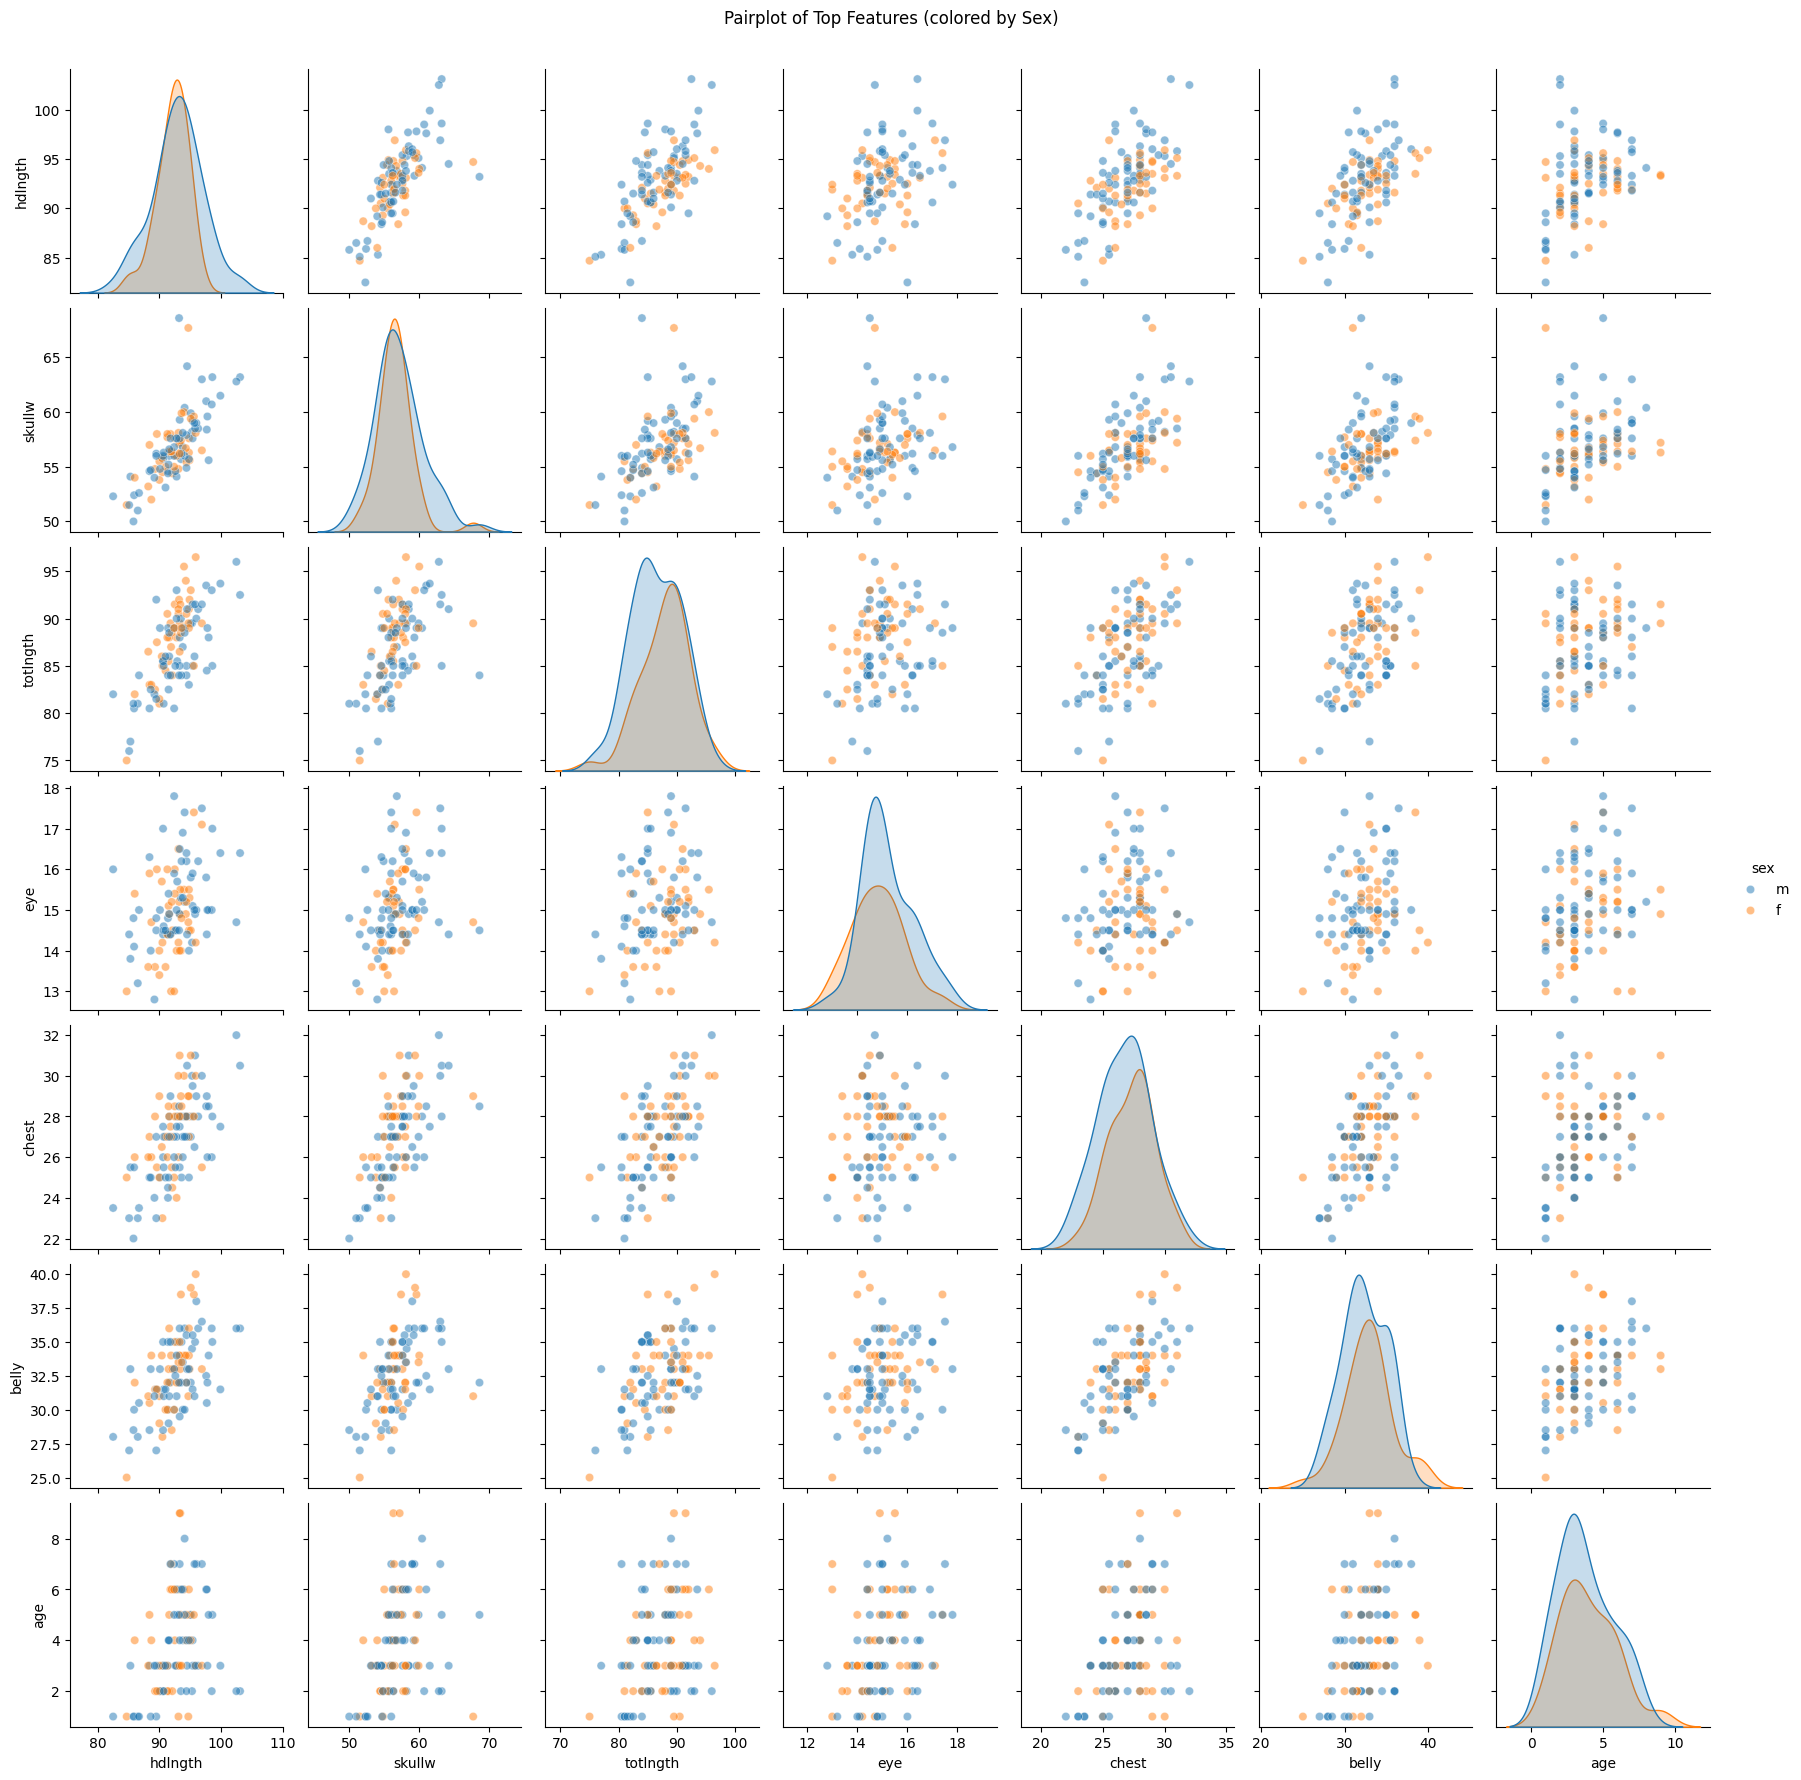

In [32]:
print("Pairplot of Top Correlated Features")
print("-----------------")

# Select features with abs correlation > 0.2 with age
top_features = corr_matrix["age"].drop("age").abs()
top_cols = top_features[top_features > 0.2].index.tolist()

sns.pairplot(df[top_cols + ["age", "sex"]], hue="sex", diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot of Top Features (colored by Sex)", y=1.02)
plt.show()

Outlier Detection
-----------------


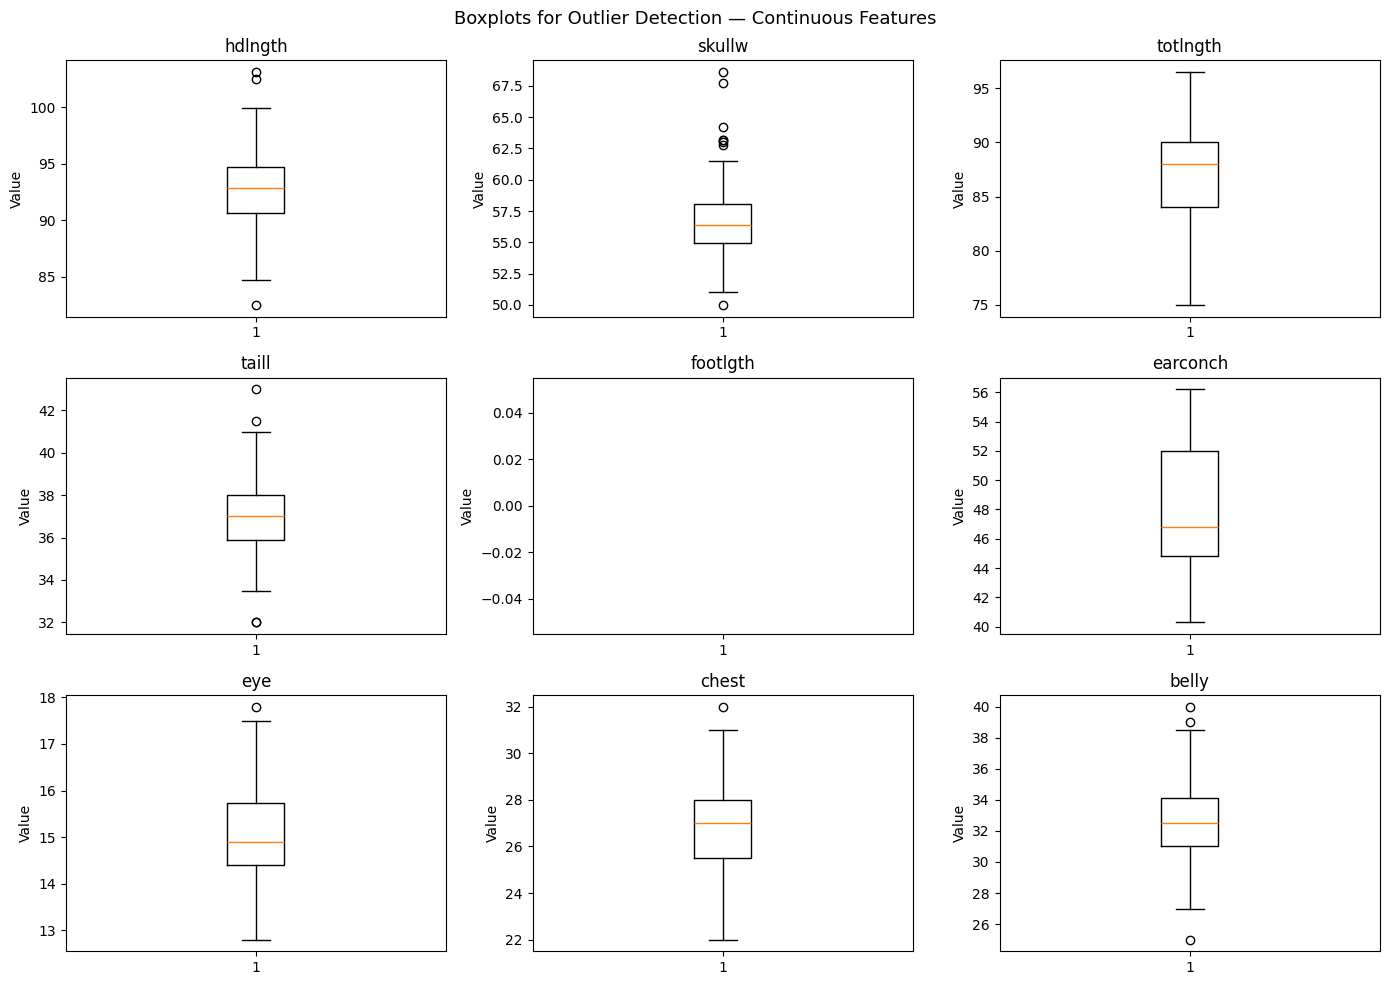

In [33]:
print("Outlier Detection")
print("-----------------")

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

plt.suptitle("Boxplots for Outlier Detection — Continuous Features", fontsize=13)
plt.tight_layout()
plt.show()

In [34]:
print("=== EDA Summary ===\n")
print(f"Observations after cleaning: {df.shape[0]}")
print(f"Features: {df.shape[1] - 1} predictors + 1 target (age)\n")

print("Sex breakdown:")
print(df["sex"].value_counts())

print("\nPopulation breakdown:")
print(df["Pop"].value_counts())

print("\nTop 3 features correlated with age:")
print(corr_matrix["age"].drop("age").abs().sort_values(ascending=False).head(3).round(3))

=== EDA Summary ===

Observations after cleaning: 104
Features: 13 predictors + 1 target (age)

Sex breakdown:
sex
m    61
f    43
Name: count, dtype: int64

Population breakdown:
Pop
other    58
Vic      46
Name: count, dtype: int64

Top 3 features correlated with age:
belly      0.354
chest      0.334
hdlngth    0.319
Name: age, dtype: float64
